<a href="https://colab.research.google.com/github/jeevaprakash-S/24ADI204_DSV_TEAM-3/blob/main/Team_3___DSV___house_prices_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Introduction

## 1.1 Objective of the Project

The objective of this project is to perform a **comprehensive Data Science workflow** on a real-world Indian real estate dataset containing house/flat listings. We aim to:

1. **Understand** the dataset structure and identify data quality issues
2. **Clean and preprocess** the data for analysis
3. **Explore** patterns, trends, and relationships through visual analysis
4. **Engineer features** and transform data for modeling readiness
5. **Perform advanced analysis** including PCA and feature selection

## 1.2 Overview of Dataset Purpose

This dataset contains **property listings from Thane, Maharashtra, India**. Each record represents a residential flat/apartment listing with details such as:
- Property title and description
- Price information (Amount and Price per sqft)
- Physical attributes (Carpet Area, Super Area, Floor, Bathrooms, Balconies)
- Categorical attributes (Location, Status, Transaction type, Furnishing, Facing, Ownership)

The dataset is sourced from a major Indian real estate portal and provides rich information for understanding the housing market dynamics in Thane.

# Chapter 2: Dataset Description

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


**What was done:** Imported all necessary libraries and set global visual settings.

**Why:** Consistent styling ensures professional-looking charts throughout the notebook.

In [ ]:
df = pd.read_csv('/content/house_prices.csv', engine='python', on_bad_lines='skip')
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nMemory Usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
df.head()

Dataset Shape: 23558 rows x 21 columns

Memory Usage: 31.62 MB


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


**What was done:** Loaded the dataset and displayed its shape.

**Interpretation:** The dataset is large-scale with ~187K listings and 21 features, making it suitable for in-depth analysis.

## 2.1 Description of All Features

In [ ]:
feature_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique(),
    'Sample Value': df.iloc[0]
})
feature_info

,Data Type,Non-Null Count,Null Count,Null %,Unique Values,Sample Value
Index,int64,23558,0,0.00,23558,0
Title,object,23558,0,0.00,5535,1 BHK Ready to Occupy Flat for sale in Srushti...
Description,object,23027,531,2.25,8255,"Bhiwandi, Thane has an attractive 1 BHK Flat f..."
Amount(in rupees),object,23558,0,0.00,866,42 Lac
Price (in rupees),float64,22393,1165,4.95,4469,6000.0
location,object,23558,0,0.00,6,thane
Carpet Area,object,11123,12435,52.78,1272,500 sqft
Status,object,23517,41,0.17,1,Ready to Move
Floor,object,22672,886,3.76,716,10 out of 11
Transaction,object,23546,12,0.05,4,Resale


**What was done:** Created a comprehensive feature summary table.

**Interpretation:** Key observations:
- `Amount(in rupees)` contains text like '42 Lac', '1.40 Cr' — needs parsing
- `Carpet Area`, `Super Area`, `Plot Area` contain text like '500 sqft' — needs cleaning
- `Price (in rupees)` is numeric (price per sqft)
- Multiple columns have significant missing values (e.g., Dimensions, Plot Area, Super Area)
- `Description` and `Title` are text-heavy columns

## 2.2 Identify Initial Issues

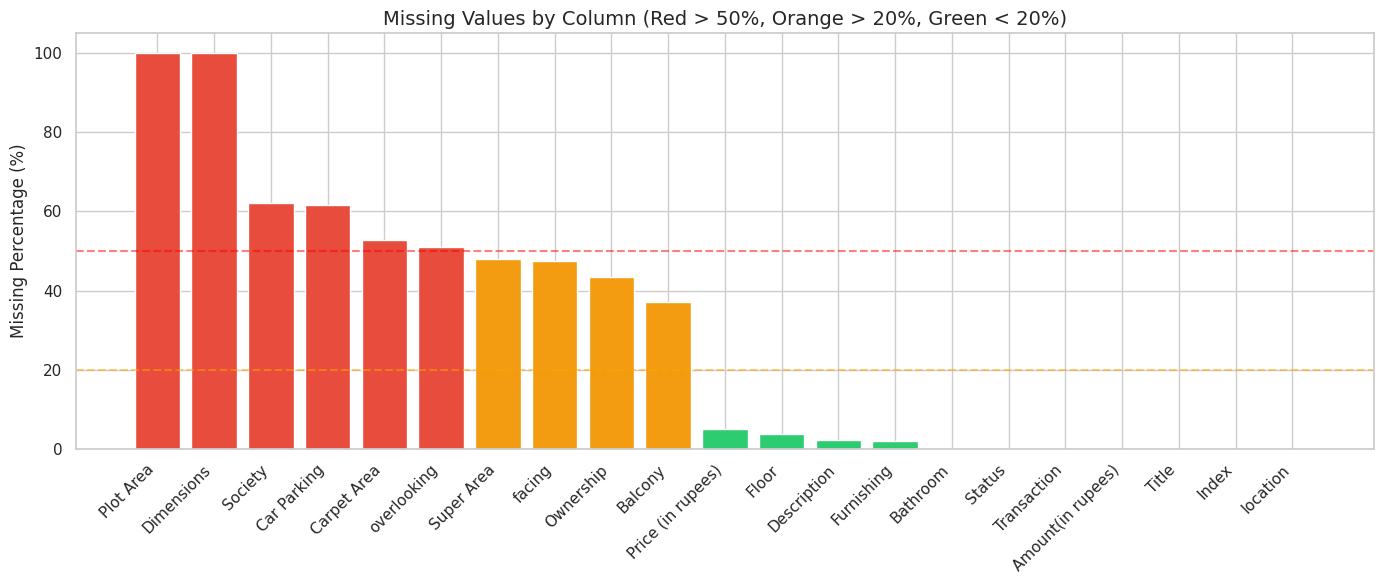

In [ ]:
# Missing values visualization
fig, ax = plt.subplots(figsize=(14, 6))
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#2ecc71' for x in missing_pct]
bars = ax.bar(range(len(missing)), missing_pct, color=colors)
ax.set_xticks(range(len(missing)))
ax.set_xticklabels(missing.index, rotation=45, ha='right')
ax.set_ylabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column (Red > 50%, Orange > 20%, Green < 20%)')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=20, color='orange', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**What was done:** Visualized missing values across all columns with color-coded thresholds.

**Interpretation:**
- **High missing (>50%):** `Dimensions`, `Plot Area`, `Super Area` — these are rarely reported
- **Moderate missing:** `facing`, `overlooking`, `Society`, `Car Parking`, `Balcony`, `Ownership`
- **Low missing:** `Price`, `Carpet Area`, `Floor` — mostly available
- Columns like `Dimensions` and `Plot Area` may need to be dropped due to extreme sparsity

In [ ]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate Index values: {df["Index"].duplicated().sum()}')

# Check Amount column format
print(f'\nSample Amount values:\n{df["Amount(in rupees)"].dropna().unique()[:10]}')

# Check Carpet Area format
print(f'\nSample Carpet Area values:\n{df["Carpet Area"].dropna().unique()[:10]}')

# Check Floor format
print(f'\nSample Floor values:\n{df["Floor"].dropna().unique()[:10]}')

Duplicate rows: 0
Duplicate Index values: 0

Sample Amount values:
['42 Lac ' '98 Lac ' '1.40 Cr ' '25 Lac ' '1.60 Cr ' '45 Lac ' '16.5 Lac '
 '60 Lac ' '1.36 Cr ' '1.35 Cr ']

Sample Carpet Area values:
['500 sqft' '473 sqft' '779 sqft' '530 sqft' '635 sqft' '550 sqft'
 '900 sqft' '950 sqft' '1820 sqft' '675 sqft']

Sample Floor values:
['10 out of 11' '3 out of 22' '10 out of 29' '1 out of 3' '20 out of 42'
 '2 out of 7' '4 out of 5' 'Ground out of 7' 'Ground out of 2'
 '3 out of 27']


**What was done:** Checked for duplicates and inspected mixed-format columns.

**Interpretation:** `Amount` contains 'Lac'/'Cr' suffixes, `Carpet Area` has 'sqft' suffix, `Floor` has '10 out of 11' format — all need cleaning.

# Chapter 3: Data Preprocessing and Cleaning

## 3.1 Data Loading and Initial Inspection

In [ ]:
# Drop columns with too many missing values or not useful for analysis
cols_to_drop = ['Index', 'Title', 'Description', 'Dimensions', 'Plot Area']
df_clean = df.drop(columns=cols_to_drop)
print(f'Dropped columns: {cols_to_drop}')
print(f'Remaining columns: {df_clean.shape[1]}')
print(f'Remaining shape: {df_clean.shape}')

Dropped columns: ['Index', 'Title', 'Description', 'Dimensions', 'Plot Area']
Remaining columns: 16
Remaining shape: (23558, 16)


**What was done:** Dropped irrelevant/sparse columns.

**Why:**
- `Index` is just a row id
- `Title` and `Description` are long text — not needed for numerical analysis
- `Dimensions` and `Plot Area` have >80% missing values

## 3.2 Converting Mixed Columns to Numeric

In [ ]:
# --- Convert Amount(in rupees) ---
def parse_amount(val):
    if pd.isna(val) or val == 'Call for Price':
        return np.nan
    val = str(val).strip()
    try:
        if 'Cr' in val:
            return float(val.replace('Cr', '').strip()) * 100  # Convert to Lac
        elif 'Lac' in val:
            return float(val.replace('Lac', '').strip())
        else:
            return float(val)
    except:
        return np.nan

df_clean['Amount_Lac'] = df_clean['Amount(in rupees)'].apply(parse_amount)
df_clean.drop(columns=['Amount(in rupees)'], inplace=True)

# --- Convert Carpet Area ---
def parse_area(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace('sqft', '').replace(',', '').strip()
    try:
        return float(val)
    except:
        return np.nan

df_clean['Carpet_Area_sqft'] = df_clean['Carpet Area'].apply(parse_area)
df_clean.drop(columns=['Carpet Area'], inplace=True)

# --- Convert Super Area ---
df_clean['Super_Area_sqft'] = df_clean['Super Area'].apply(parse_area)
df_clean.drop(columns=['Super Area'], inplace=True)

# --- Parse Floor info ---
def parse_floor_current(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    parts = val.split(' out of ')
    floor_str = parts[0].strip()
    if floor_str.lower() in ['ground', 'lower basement', 'upper basement']:
        return 0
    try:
        return int(floor_str)
    except:
        return np.nan

def parse_floor_total(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    parts = val.split(' out of ')
    if len(parts) == 2:
        try:
            return int(parts[1].strip())
        except:
            return np.nan
    return np.nan

df_clean['Current_Floor'] = df_clean['Floor'].apply(parse_floor_current)
df_clean['Total_Floors'] = df_clean['Floor'].apply(parse_floor_total)
df_clean.drop(columns=['Floor'], inplace=True)

# --- Parse Car Parking ---
def parse_parking(val):
    if pd.isna(val):
        return 0
    val = str(val).strip()
    try:
        return int(val.split()[0])
    except:
        return 0

df_clean['Car_Parking_Count'] = df_clean['Car Parking'].apply(parse_parking)
df_clean.drop(columns=['Car Parking'], inplace=True)

# Convert Bathroom and Balcony to numeric
df_clean['Bathroom'] = pd.to_numeric(df_clean['Bathroom'], errors='coerce')
df_clean['Balcony'] = pd.to_numeric(df_clean['Balcony'], errors='coerce')

print('Conversions complete.')
df_clean.dtypes

Conversions complete.


,0
Price (in rupees),float64
location,object
Status,object
Transaction,object
Furnishing,object
facing,object
overlooking,object
Society,object
Bathroom,float64
Balcony,float64


**What was done:** Parsed all mixed-format columns:
- `Amount`: Converted 'Lac'/'Cr' text to numeric (in Lakhs)
- `Carpet Area` & `Super Area`: Removed 'sqft' text
- `Floor`: Extracted current floor and total floors as separate numeric columns
- `Car Parking`: Extracted numeric count

**Why:** Machine learning and statistical analysis require numeric data. These transformations preserve the information while enabling computation.

## 3.3 Handling Missing Values

In [ ]:
# Check missing values after conversion
missing_after = df_clean.isnull().sum()
missing_after_pct = (missing_after / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing_after, 'Percentage': missing_after_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df.to_string())

# Fill numeric columns with median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'Filled {col} with median: {median_val}')

# Fill categorical columns with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'Filled {col} with mode: {mode_val}')

print(f'\nRemaining nulls: {df_clean.isnull().sum().sum()}')

                   Count  Percentage
Carpet_Area_sqft   14977       63.58
Society            14657       62.22
Super_Area_sqft    12965       55.03
overlooking        12006       50.96
facing             11198       47.53
Ownership          10246       43.49
Balcony             8764       37.20
Price (in rupees)   1165        4.95
Total_Floors         890        3.78
Current_Floor        886        3.76
Amount_Lac           489        2.08
Furnishing           460        1.95
Bathroom              55        0.23
Status                41        0.17
Transaction           12        0.05
Filled Price (in rupees) with median: 5576.0
Filled Bathroom with median: 2.0
Filled Balcony with median: 2.0
Filled Amount_Lac with median: 78.0
Filled Carpet_Area_sqft with median: 900.0
Filled Super_Area_sqft with median: 1332.0
Filled Current_Floor with median: 3.0
Filled Total_Floors with median: 7.0
Filled Status with mode: Ready to Move
Filled Transaction with mode: Resale
Filled Furnishing with mo

**What was done:** Filled missing values using:
- **Median** for numeric columns (robust to outliers)
- **Mode** for categorical columns (most frequent category)

**Why:** Median is preferred over mean for skewed distributions (common in real estate prices). Mode preserves the dominant category distribution.

## 3.4 Outlier Detection

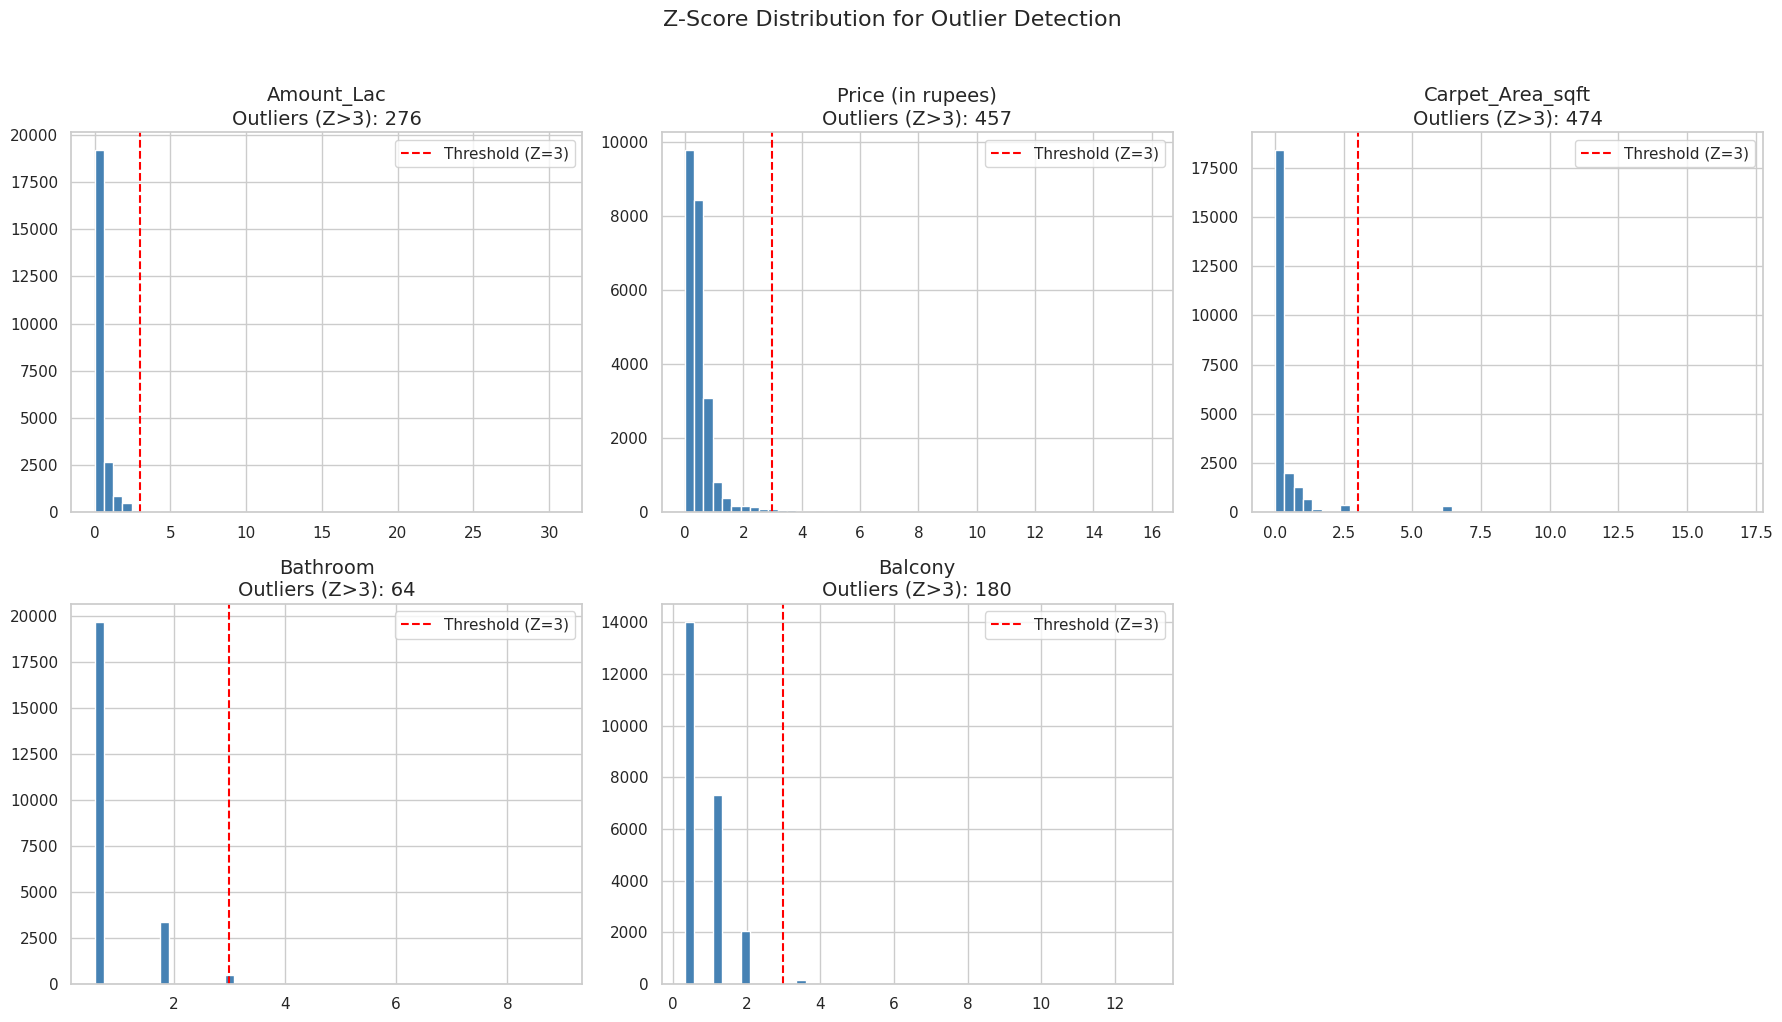

In [ ]:
from scipy import stats

# Z-Score method
key_numeric = ['Amount_Lac', 'Price (in rupees)', 'Carpet_Area_sqft', 'Bathroom', 'Balcony']
key_numeric = [c for c in key_numeric if c in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    z_scores = np.abs(stats.zscore(df_clean[col].dropna()))
    outlier_count = (z_scores > 3).sum()
    axes[i].hist(z_scores, bins=50, color='steelblue', edgecolor='white')
    axes[i].axvline(x=3, color='red', linestyle='--', label=f'Threshold (Z=3)')
    axes[i].set_title(f'{col}\nOutliers (Z>3): {outlier_count}')
    axes[i].legend()
if len(key_numeric) < 6:
    for j in range(len(key_numeric), 6):
        axes[j].set_visible(False)
plt.suptitle('Z-Score Distribution for Outlier Detection', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**What was done:** Applied Z-Score method to detect outliers (|Z| > 3).

**Interpretation:** Real estate data naturally has extreme values (luxury vs budget properties), so outliers are expected. We keep them for analysis but note their presence.

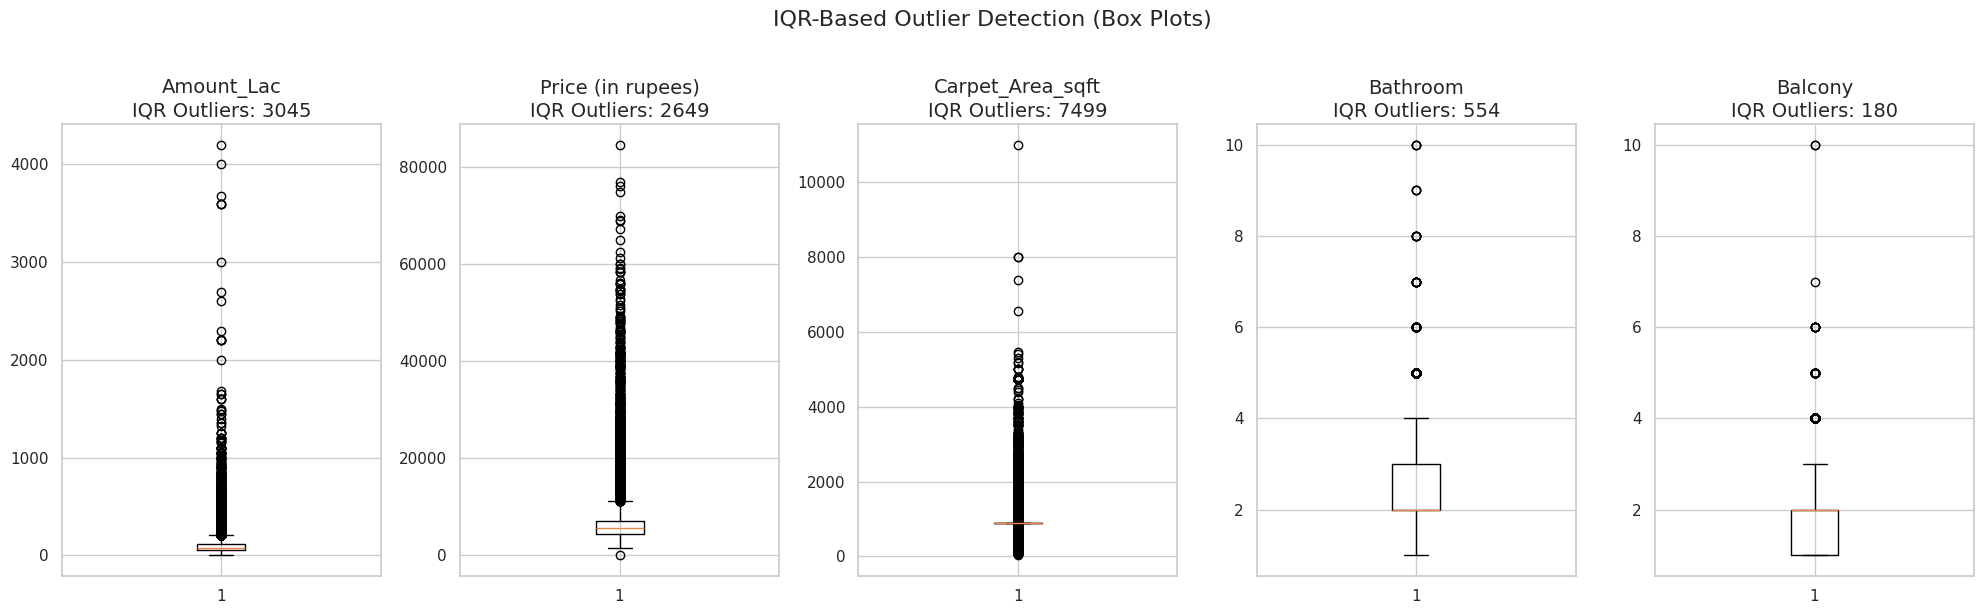

In [ ]:
# IQR method
fig, axes = plt.subplots(1, len(key_numeric), figsize=(4*len(key_numeric), 6))
if len(key_numeric) == 1:
    axes = [axes]
for i, col in enumerate(key_numeric):
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    axes[i].boxplot(df_clean[col].dropna(), vert=True)
    axes[i].set_title(f'{col}\nIQR Outliers: {outliers}')
plt.suptitle('IQR-Based Outlier Detection (Box Plots)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**What was done:** Applied IQR method and visualized with box plots.

**Interpretation:** The IQR method confirms significant right-skew in price and area columns — this is typical for property markets where a few premium listings inflate the upper range.

## 3.5 Data Quality Report Summary

In [ ]:
print('='*60)
print('DATA QUALITY REPORT SUMMARY')
print('='*60)
print(f'Total Records: {len(df_clean)}')
print(f'Total Features: {df_clean.shape[1]}')
print(f'Numeric Features: {len(df_clean.select_dtypes(include=[np.number]).columns)}')
print(f'Categorical Features: {len(df_clean.select_dtypes(include=["object"]).columns)}')
print(f'Missing Values Remaining: {df_clean.isnull().sum().sum()}')
print(f'Duplicate Rows: {df_clean.duplicated().sum()}')
print('\nNumeric Column Statistics:')
print(df_clean.describe().to_string())
print('='*60)

DATA QUALITY REPORT SUMMARY
Total Records: 23558
Total Features: 17
Numeric Features: 9
Categorical Features: 8
Missing Values Remaining: 0
Duplicate Rows: 15044

Numeric Column Statistics:
       Price (in rupees)      Bathroom       Balcony    Amount_Lac  Carpet_Area_sqft  Super_Area_sqft  Current_Floor  Total_Floors  Car_Parking_Count
count       23558.000000  23558.000000  23558.000000  23558.000000      23558.000000     23558.000000   23558.000000  23558.000000       23558.000000
mean         6873.627175      2.484124      1.795017    113.020307       1028.437091      1412.719586       4.709058      9.563248           0.938874
std          4884.513267      0.841710      0.634076    133.352520        589.396567       639.066749       5.115891      7.009770          13.020574
min            17.000000      1.000000      1.000000      2.000000         30.000000        27.000000       0.000000      1.000000           0.000000
25%          4500.000000      2.000000      1.000000     58.

**What was done:** Generated a summary quality report.

**Interpretation:** After cleaning, the dataset is free of missing values, mixed formats have been resolved, and we have a clear separation of numeric and categorical features ready for EDA.

# Chapter 4: Exploratory Data Analysis (EDA)

## 4.1 Univariate Analysis

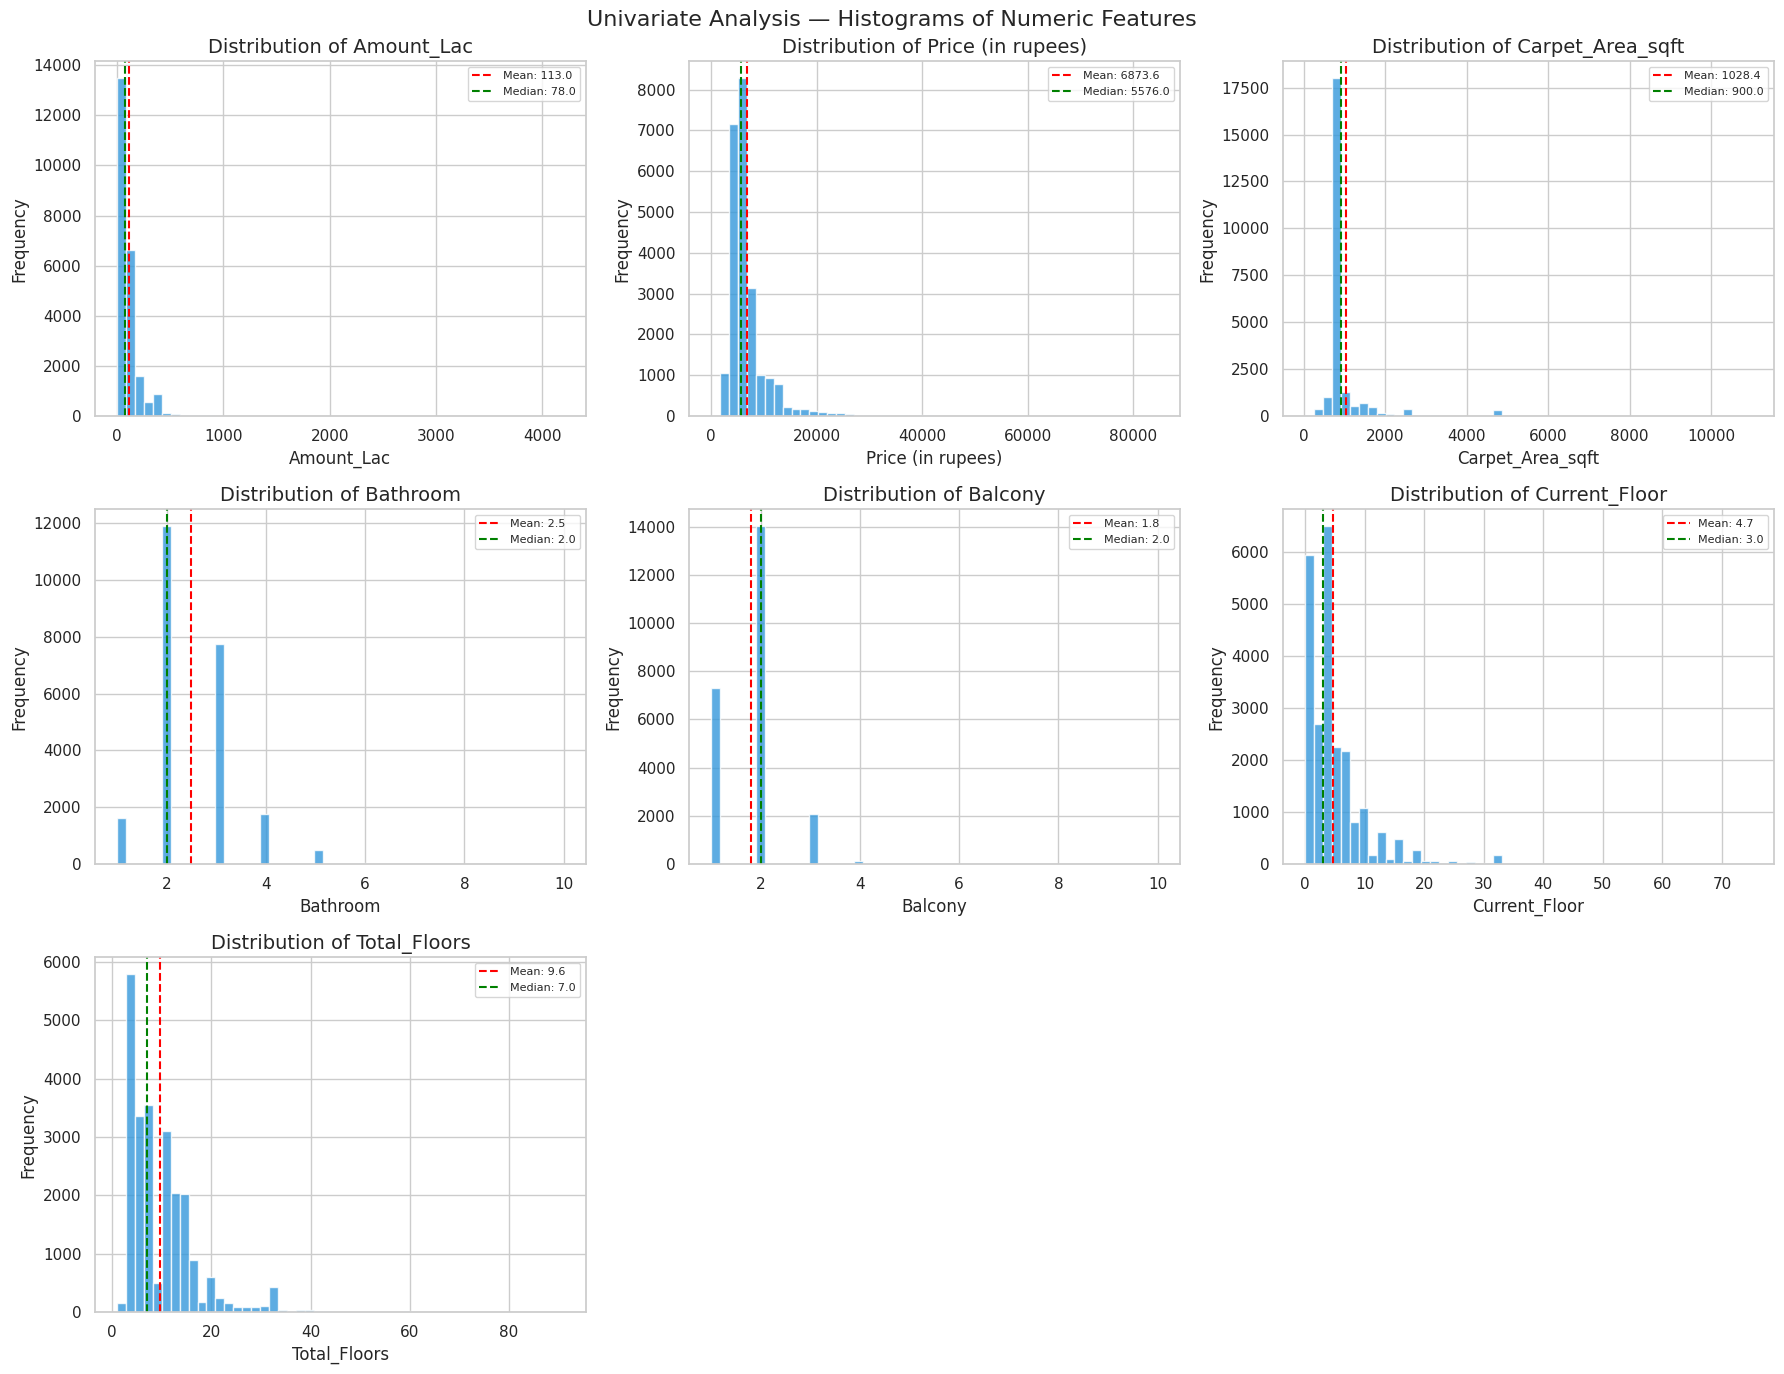

In [ ]:
# Histograms for key numeric features
num_features = ['Amount_Lac', 'Price (in rupees)', 'Carpet_Area_sqft', 'Bathroom', 'Balcony', 'Current_Floor', 'Total_Floors']
num_features = [c for c in num_features if c in df_clean.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df_clean[col].dropna(), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.1f}')
    axes[i].axvline(df_clean[col].median(), color='green', linestyle='--', label=f'Median: {df_clean[col].median():.1f}')
    axes[i].legend(fontsize=8)
for j in range(len(num_features), 9):
    axes[j].set_visible(False)
plt.suptitle('Univariate Analysis — Histograms of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

**What was done:** Created histograms with mean and median markers for all numeric features.

**Key Insights:**
- **Amount_Lac:** Heavily right-skewed — most properties are in the budget range (under 100 Lac)
- **Price per sqft:** Also right-skewed with concentration around 5000-15000 Rs/sqft
- **Carpet Area:** Majority of flats are 400-800 sqft (1-2 BHK range)
- **Bathroom:** Most properties have 1-2 bathrooms
- Mean > Median in most columns confirms positive skewness

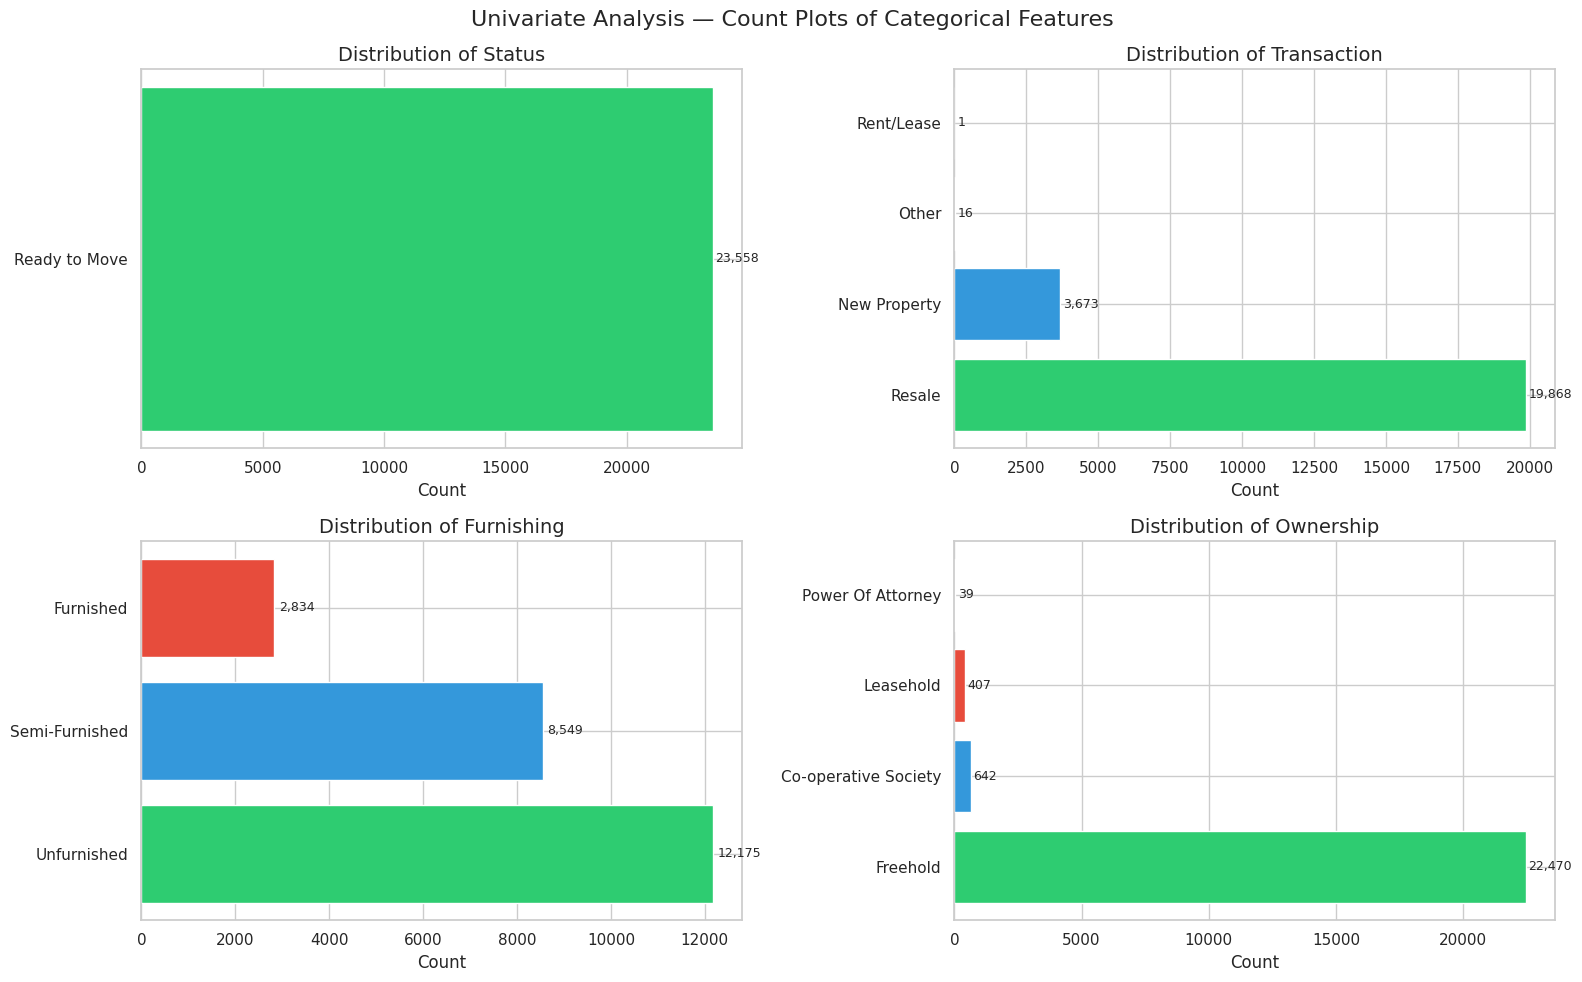

In [ ]:
# Count plots for categorical features
cat_features = ['Status', 'Transaction', 'Furnishing', 'Ownership']
cat_features = [c for c in cat_features if c in df_clean.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
palette = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
for i, col in enumerate(cat_features):
    counts = df_clean[col].value_counts().head(6)
    axes[i].barh(counts.index, counts.values, color=palette[:len(counts)])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    for idx, val in enumerate(counts.values):
        axes[i].text(val + 100, idx, f'{val:,}', va='center', fontsize=9)
plt.suptitle('Univariate Analysis — Count Plots of Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()

**What was done:** Created horizontal bar charts for key categorical features.

**Key Insights:**
- **Status:** Overwhelmingly 'Ready to Move' — very few under construction
- **Transaction:** Mostly 'Resale' properties
- **Furnishing:** Mix of Unfurnished, Semi-Furnished, and Furnished
- **Ownership:** Freehold dominates over Co-operative Society and others
- This reveals a dataset **imbalance** in Status and Transaction columns

## 4.2 Bivariate Analysis

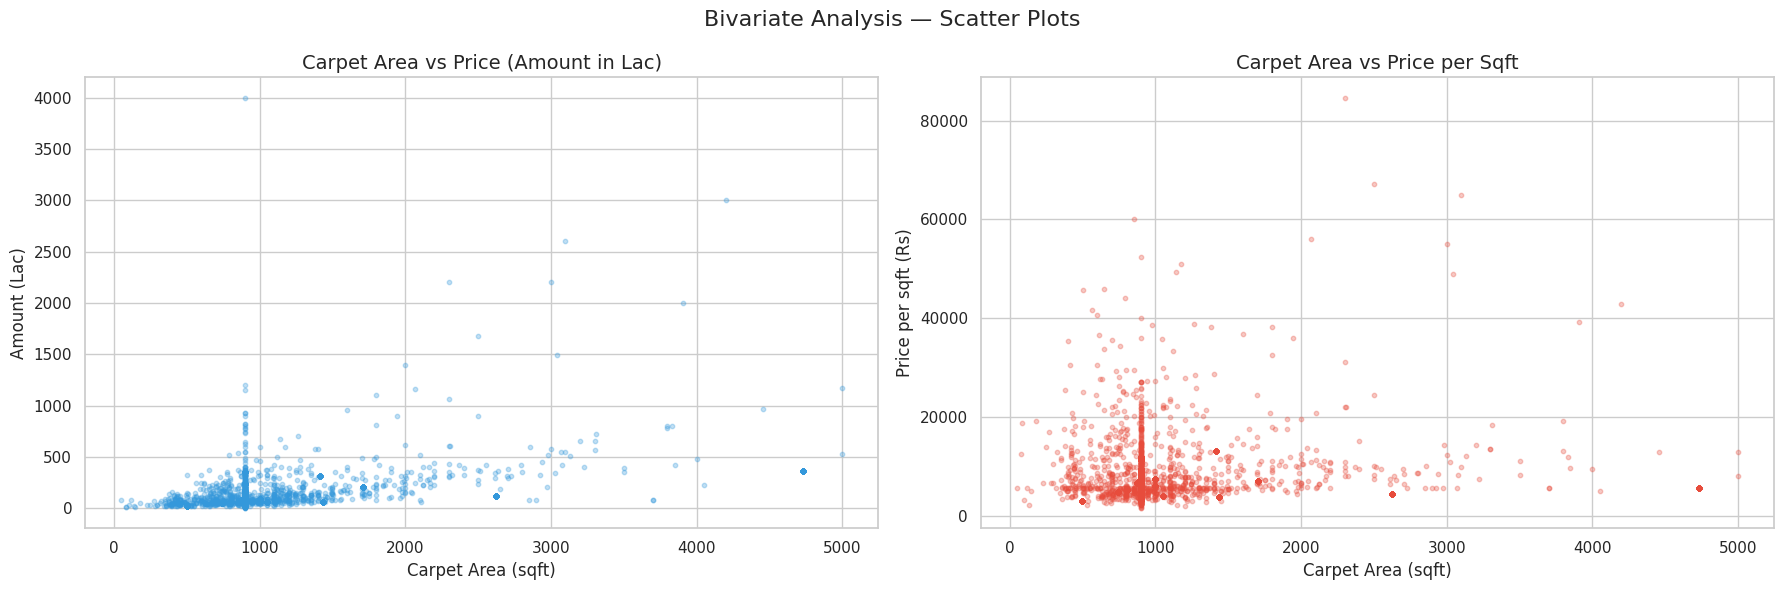

In [ ]:
# Scatter plot: Carpet Area vs Amount
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

axes[0].scatter(sample['Carpet_Area_sqft'], sample['Amount_Lac'], alpha=0.3, s=10, c='#3498db')
axes[0].set_xlabel('Carpet Area (sqft)')
axes[0].set_ylabel('Amount (Lac)')
axes[0].set_title('Carpet Area vs Price (Amount in Lac)')

axes[1].scatter(sample['Carpet_Area_sqft'], sample['Price (in rupees)'], alpha=0.3, s=10, c='#e74c3c')
axes[1].set_xlabel('Carpet Area (sqft)')
axes[1].set_ylabel('Price per sqft (Rs)')
axes[1].set_title('Carpet Area vs Price per Sqft')

plt.suptitle('Bivariate Analysis — Scatter Plots', fontsize=16)
plt.tight_layout()
plt.show()

**What was done:** Scatter plots examining relationship between area and price.

**Key Insights:**
- Strong positive correlation between Carpet Area and Amount
- Price per sqft shows more variability — influenced by location and amenities

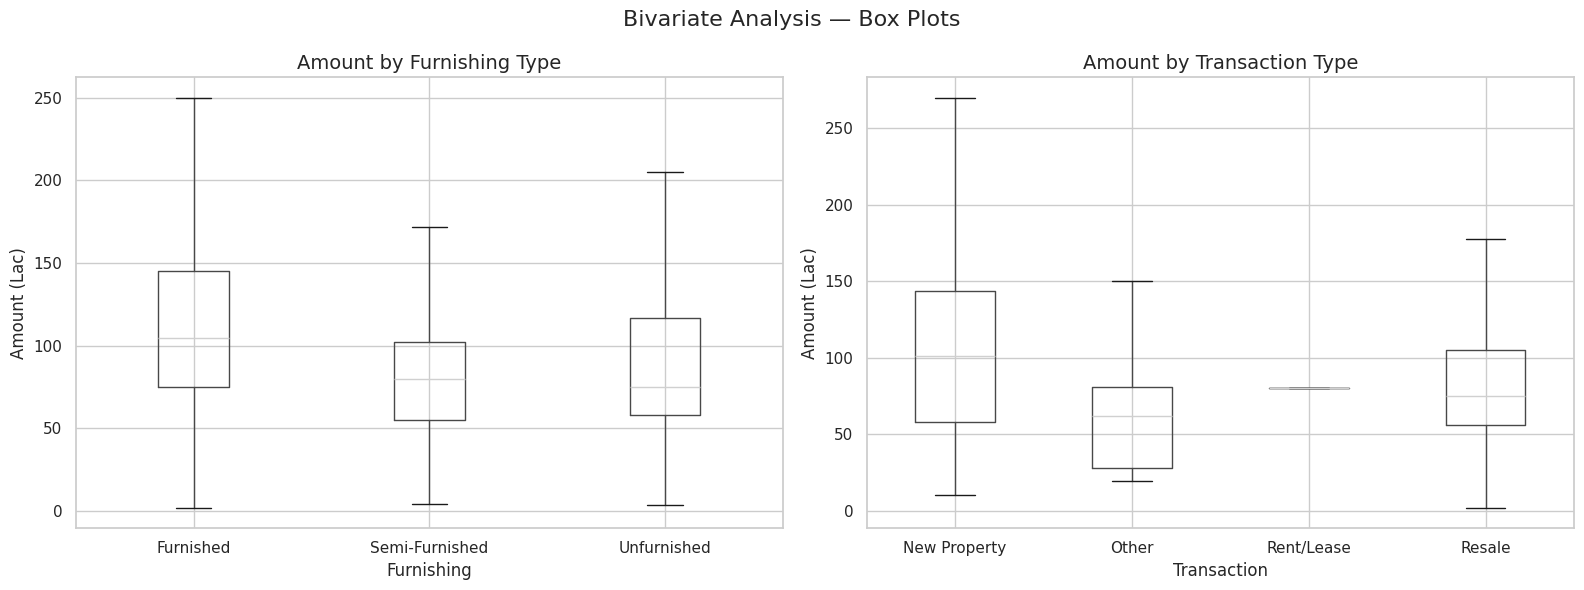

In [ ]:
# Box plots: Furnishing vs Amount
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_clean.boxplot(column='Amount_Lac', by='Furnishing', ax=axes[0], showfliers=False)
axes[0].set_title('Amount by Furnishing Type')
axes[0].set_xlabel('Furnishing')
axes[0].set_ylabel('Amount (Lac)')

df_clean.boxplot(column='Amount_Lac', by='Transaction', ax=axes[1], showfliers=False)
axes[1].set_title('Amount by Transaction Type')
axes[1].set_xlabel('Transaction')
axes[1].set_ylabel('Amount (Lac)')

plt.suptitle('Bivariate Analysis — Box Plots', fontsize=16)
plt.tight_layout()
plt.show()

**What was done:** Box plots comparing price distributions across categories.

**Key Insights:**
- Furnished properties tend to have slightly higher median prices
- New Property transactions show higher prices than Resale — likely due to builder premiums

## 4.3 Multivariate Analysis

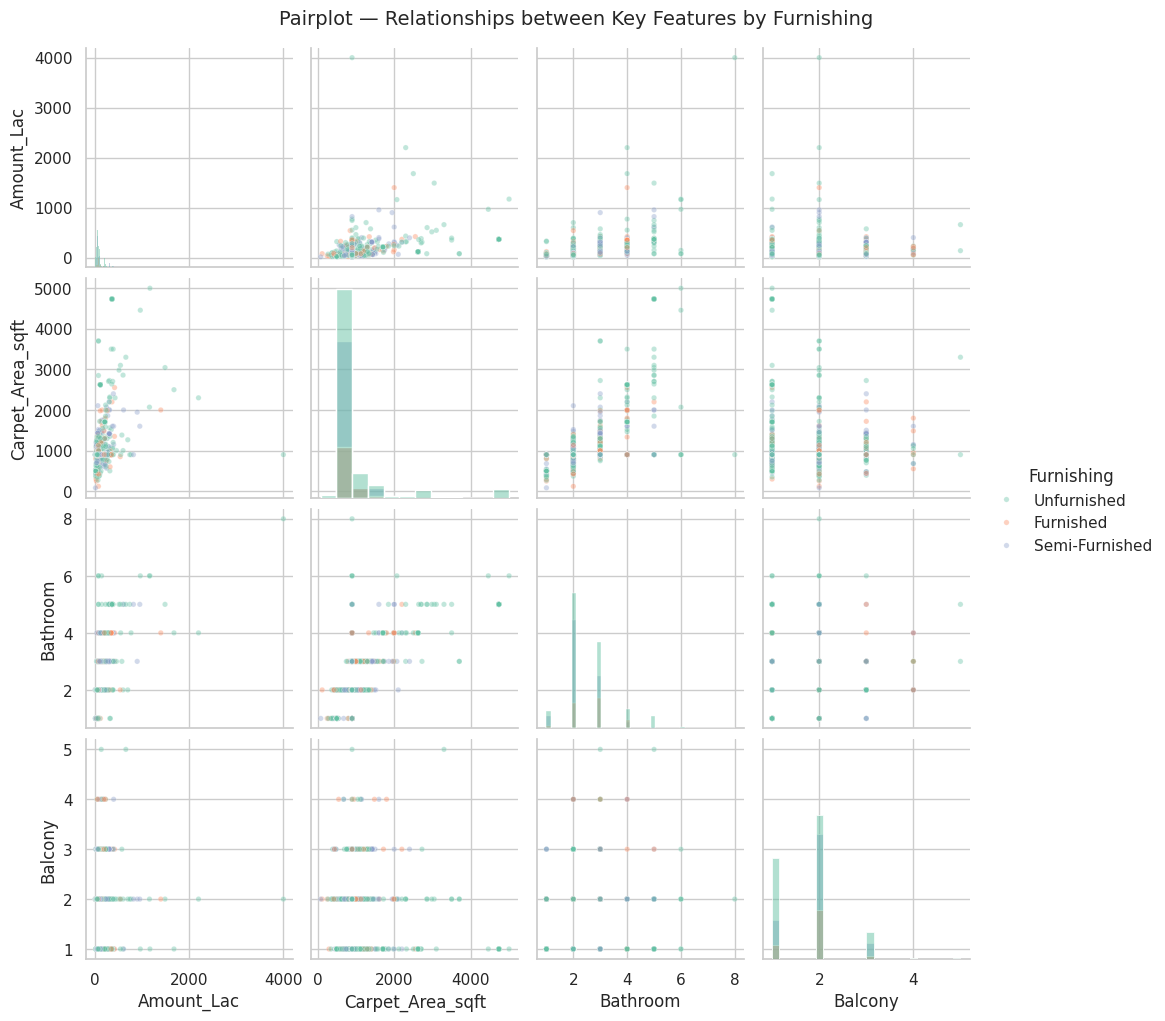

In [ ]:
# Pairplot on sampled data
pair_cols = ['Amount_Lac', 'Carpet_Area_sqft', 'Bathroom', 'Balcony', 'Furnishing']
pair_cols = [c for c in pair_cols if c in df_clean.columns]
sample_pair = df_clean[pair_cols].sample(min(2000, len(df_clean)), random_state=42).dropna()

g = sns.pairplot(sample_pair, hue='Furnishing', palette='Set2', diag_kind='hist',
                 plot_kws={'alpha': 0.4, 's': 15}, height=2.5)
g.figure.suptitle('Pairplot — Relationships between Key Features by Furnishing', y=1.02, fontsize=14)
plt.show()

**What was done:** Pairplot colored by Furnishing type to observe multivariate patterns.

**Key Insights:**
- Carpet Area and Amount show clear positive linear trend
- Bathroom count correlates with both area and price
- Furnished properties (colored differently) tend to cluster at higher price points

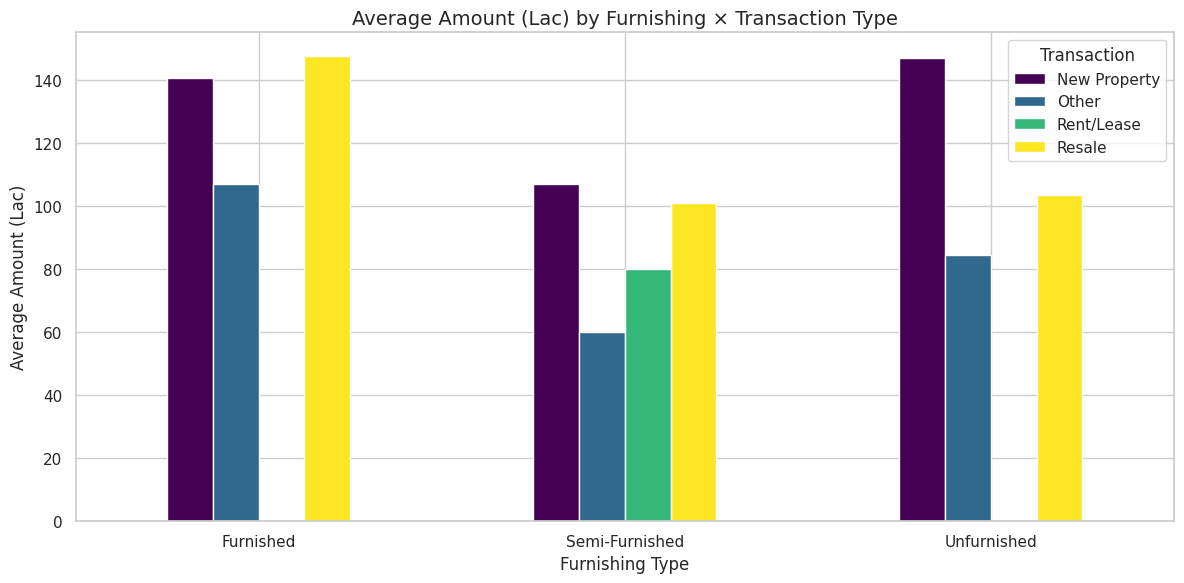

In [ ]:
# Group-based analysis: Average price by Furnishing and Transaction
fig, ax = plt.subplots(figsize=(12, 6))
grouped = df_clean.groupby(['Furnishing', 'Transaction'])['Amount_Lac'].mean().unstack()
grouped.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Average Amount (Lac) by Furnishing × Transaction Type')
ax.set_ylabel('Average Amount (Lac)')
ax.set_xlabel('Furnishing Type')
plt.xticks(rotation=0)
plt.legend(title='Transaction')
plt.tight_layout()
plt.show()

**What was done:** Grouped bar chart showing mean price by Furnishing and Transaction combinations.

**Key Insights:**
- New properties are consistently priced higher than resale across all furnishing types
- Furnished + New Property is the most expensive segment

# Chapter 5: Data Transformation and Feature Engineering

## 5.1 Encoding Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

df_encoded = df_clean.copy()

# Label Encoding for ordinal-like columns
le_cols = ['Status', 'Transaction', 'Furnishing', 'Ownership']
le_cols = [c for c in le_cols if c in df_encoded.columns]
le_dict = {}
for col in le_cols:
    le = LabelEncoder()
    df_encoded[col + '_LE'] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {le_dict[col]}')

# One-Hot Encoding for nominal columns
ohe_cols = ['facing']
ohe_cols = [c for c in ohe_cols if c in df_encoded.columns]
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, prefix=ohe_cols, drop_first=True)

# Drop original categorical columns
drop_cats = ['location', 'overlooking', 'Society'] + le_cols
drop_cats = [c for c in drop_cats if c in df_encoded.columns]
df_encoded.drop(columns=drop_cats, inplace=True)

print(f'\nEncoded shape: {df_encoded.shape}')
df_encoded.head()

Status: {'Ready to Move': np.int64(0)}
Transaction: {'New Property': np.int64(0), 'Other': np.int64(1), 'Rent/Lease': np.int64(2), 'Resale': np.int64(3)}
Furnishing: {'Furnished': np.int64(0), 'Semi-Furnished': np.int64(1), 'Unfurnished': np.int64(2)}
Ownership: {'Co-operative Society': np.int64(0), 'Freehold': np.int64(1), 'Leasehold': np.int64(2), 'Power Of Attorney': np.int64(3)}

Encoded shape: (23558, 20)


,Price (in rupees),Bathroom,Balcony,Amount_Lac,Carpet_Area_sqft,Super_Area_sqft,Current_Floor,Total_Floors,Car_Parking_Count,Status_LE,Transaction_LE,Furnishing_LE,Ownership_LE,facing_North,facing_North - East,facing_North - West,facing_South,facing_South - East,facing_South -West,facing_West
0,6000.0,1.0,2.0,42.0,500.0,1332.0,10.0,11.0,0,0,3,2,1,False,False,False,False,False,False,False
1,13799.0,2.0,2.0,98.0,473.0,1332.0,3.0,22.0,1,0,3,1,1,False,False,False,False,False,False,False
2,17500.0,2.0,2.0,140.0,779.0,1332.0,10.0,29.0,1,0,3,2,1,False,False,False,False,False,False,False
3,5576.0,1.0,1.0,25.0,530.0,1332.0,1.0,3.0,0,0,3,2,1,False,False,False,False,False,False,False
4,18824.0,2.0,2.0,160.0,635.0,1332.0,20.0,42.0,1,0,3,2,0,False,False,False,False,False,False,True


**What was done:**
- **Label Encoding** for ordinal/binary-like columns (Status, Transaction, Furnishing, Ownership)
- **One-Hot Encoding** for nominal columns (facing)
- Dropped high-cardinality text columns (location, Society, overlooking)

**Why:** Label encoding preserves ordinal relationships while One-Hot encoding prevents false ordering in purely nominal categories.

## 5.2 Feature Scaling

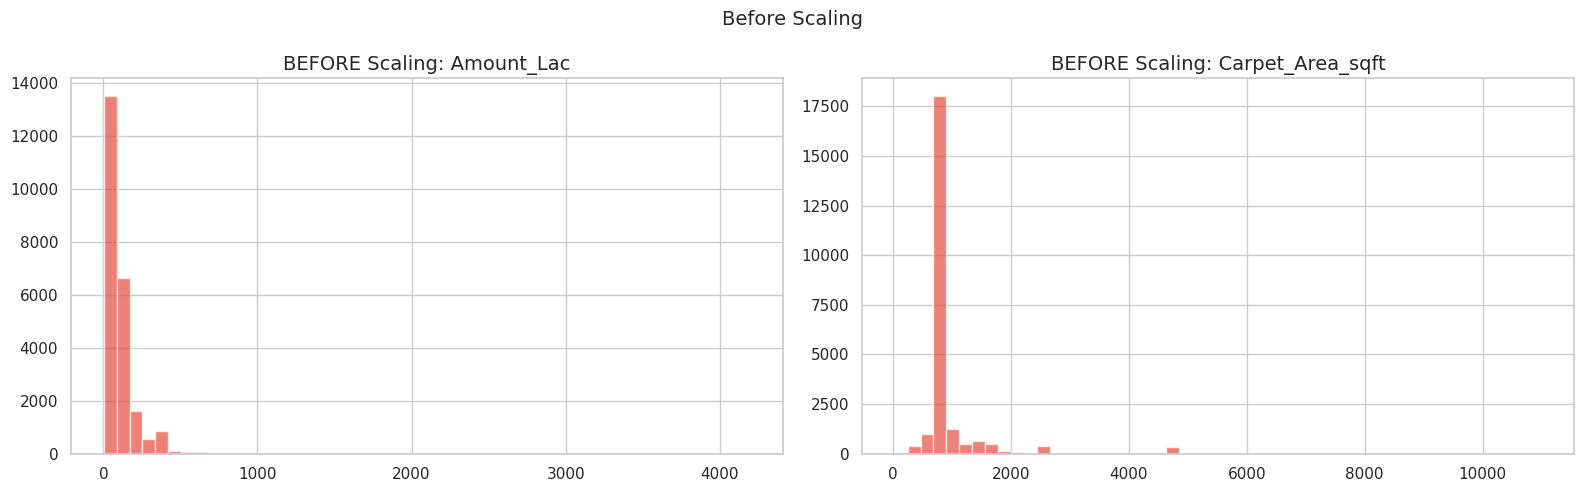

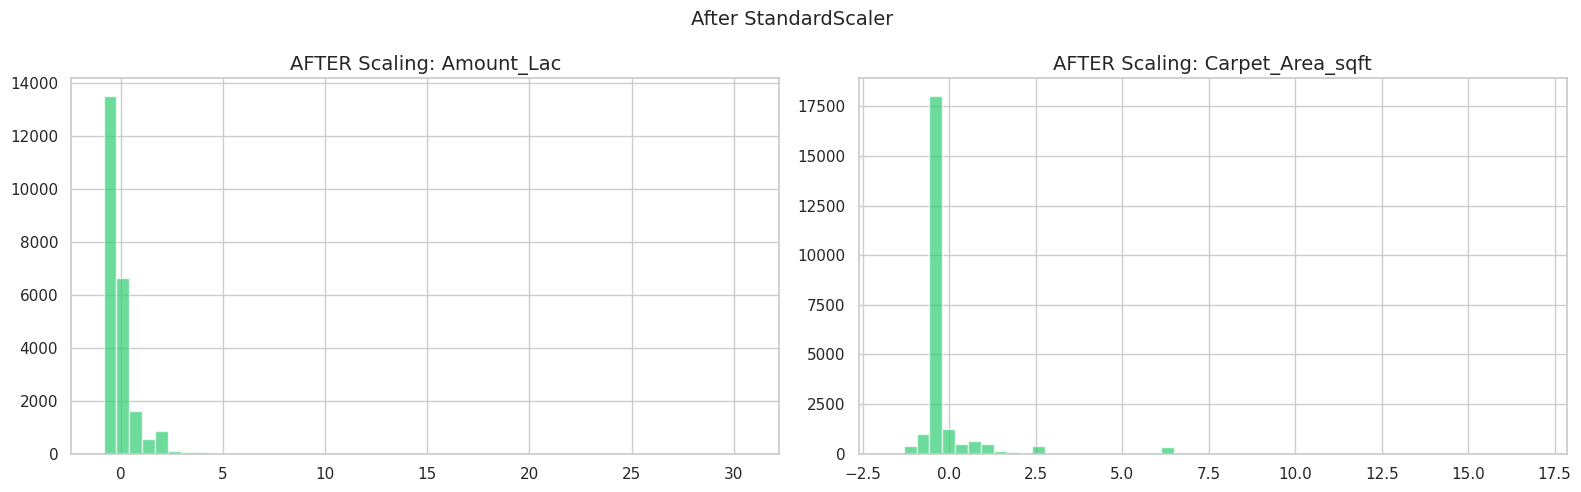

In [ ]:
# Select only numeric columns for scaling
numeric_for_scale = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Before scaling - show distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sample_cols = ['Amount_Lac', 'Carpet_Area_sqft']
sample_cols = [c for c in sample_cols if c in df_encoded.columns]
for i, col in enumerate(sample_cols):
    axes[i].hist(df_encoded[col], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'BEFORE Scaling: {col}')
plt.suptitle('Before Scaling', fontsize=14)
plt.tight_layout()
plt.show()

# Apply StandardScaler
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numeric_for_scale] = scaler.fit_transform(df_encoded[numeric_for_scale])

# After scaling
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, col in enumerate(sample_cols):
    axes[i].hist(df_scaled[col], bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'AFTER Scaling: {col}')
plt.suptitle('After StandardScaler', fontsize=14)
plt.tight_layout()
plt.show()

**What was done:** Applied StandardScaler to normalize all numeric features (mean=0, std=1).

**Why:** Scaling ensures all features contribute equally in distance-based algorithms and PCA. The before/after comparison shows the shift to zero-centered distributions.

## 5.3 Handling Skewness

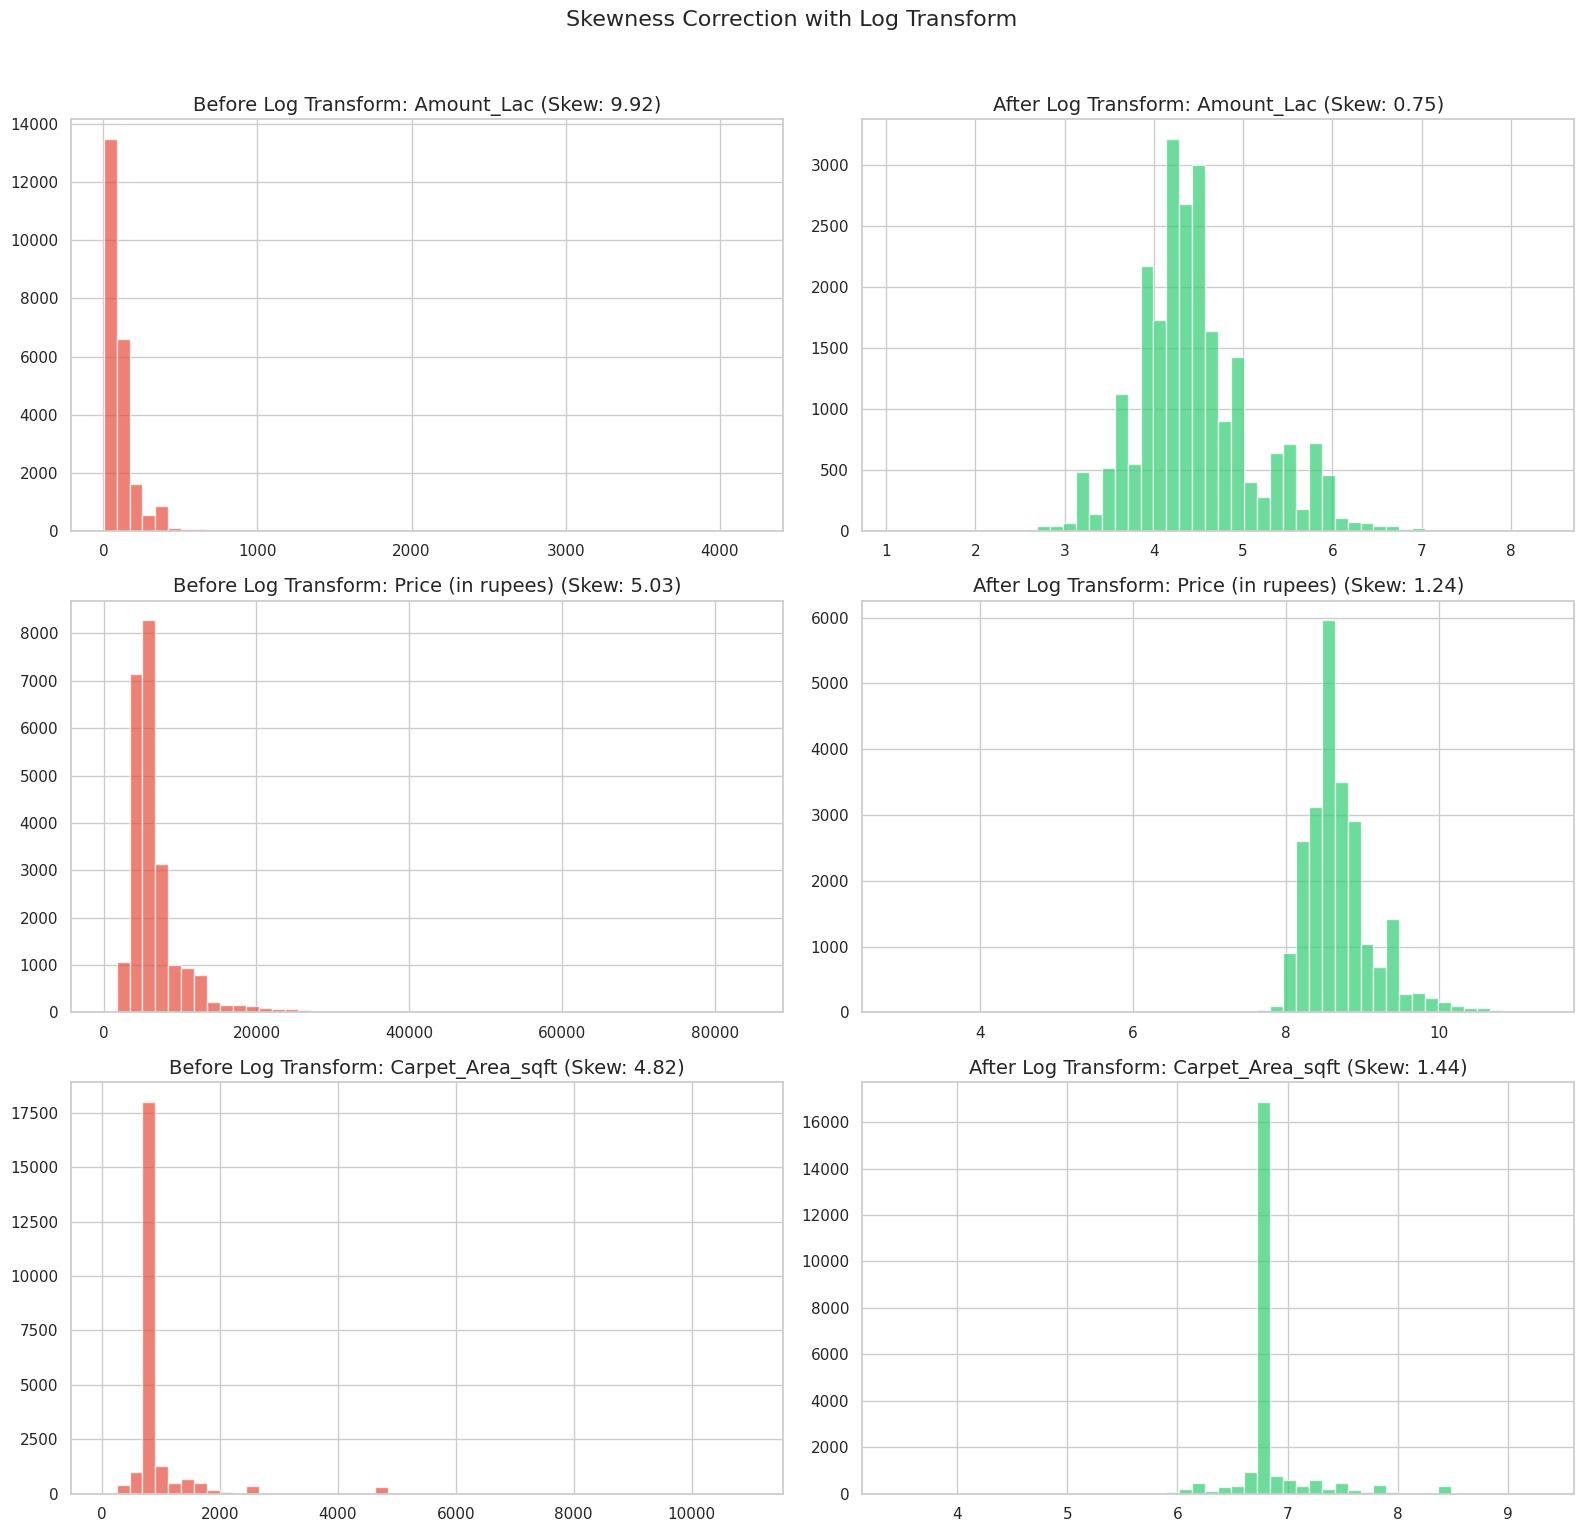

In [ ]:
# Check skewness and apply log transform
skew_cols = ['Amount_Lac', 'Price (in rupees)', 'Carpet_Area_sqft']
skew_cols = [c for c in skew_cols if c in df_encoded.columns]

fig, axes = plt.subplots(len(skew_cols), 2, figsize=(16, 5*len(skew_cols)))
for i, col in enumerate(skew_cols):
    # Before
    axes[i, 0].hist(df_encoded[col], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[i, 0].set_title(f'Before Log Transform: {col} (Skew: {df_encoded[col].skew():.2f})')
    # After
    log_data = np.log1p(df_encoded[col].clip(lower=0))
    axes[i, 1].hist(log_data, bins=50, color='#2ecc71', alpha=0.7, edgecolor='white')
    axes[i, 1].set_title(f'After Log Transform: {col} (Skew: {log_data.skew():.2f})')
plt.suptitle('Skewness Correction with Log Transform', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**What was done:** Applied log1p transform to highly skewed columns and visualized before vs after.

**Interpretation:** Log transformation significantly reduces skewness, making distributions more normal — important for parametric statistical methods and linear models.

## 5.4 Feature Creation

In [ ]:
# Create new meaningful features
df_feat = df_encoded.copy()

# Price per bathroom
df_feat['Price_per_Bathroom'] = df_feat['Amount_Lac'] / df_feat['Bathroom'].replace(0, 1)

# Floor ratio (how high up in the building)
df_feat['Floor_Ratio'] = df_feat['Current_Floor'] / df_feat['Total_Floors'].replace(0, 1)

# Total amenity score
df_feat['Amenity_Score'] = df_feat['Bathroom'] + df_feat['Balcony'] + df_feat['Car_Parking_Count']

print('New features created:')
print(df_feat[['Price_per_Bathroom', 'Floor_Ratio', 'Amenity_Score']].describe().to_string())

New features created:
       Price_per_Bathroom   Floor_Ratio  Amenity_Score
count        23558.000000  23558.000000   23558.000000
mean            42.891693      0.475624       5.218015
std             37.523927      0.283923      13.068454
min              1.950000      0.000000       2.000000
25%             26.000000      0.250000       4.000000
50%             34.000000      0.428571       5.000000
75%             45.000000      0.700000       5.000000
max           1800.000000      1.000000     711.000000


**What was done:** Created 3 new derived features:
- **Price_per_Bathroom:** Normalizes price by number of bathrooms (proxy for property size)
- **Floor_Ratio:** Captures relative floor position (higher floors may command premiums)
- **Amenity_Score:** Composite score combining bathroom, balcony, and parking

**Why:** Feature engineering helps capture non-obvious relationships and can improve model performance.

# Chapter 6: Advanced Analysis

## 6.1 Correlation Analysis

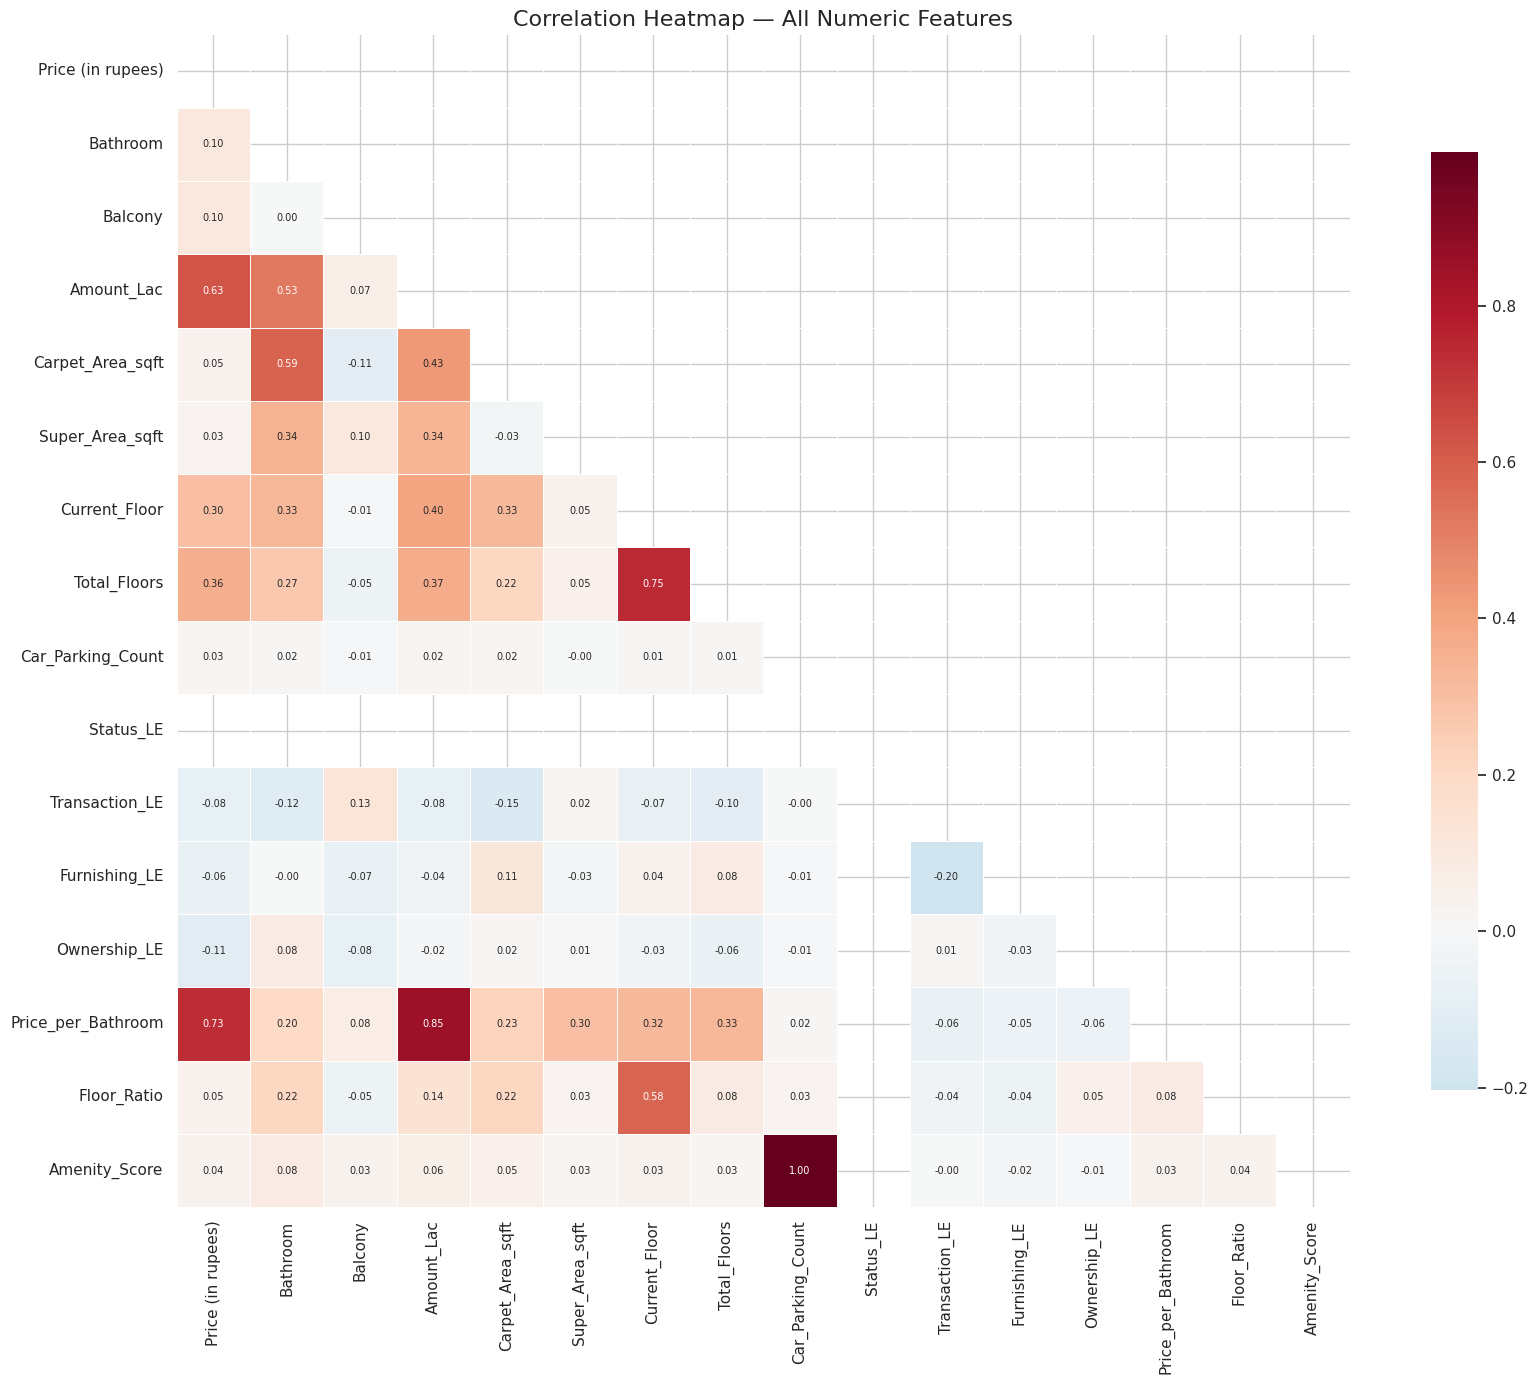

In [ ]:
# Correlation heatmap
numeric_df = df_feat.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — All Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

**What was done:** Generated a lower-triangular heatmap showing pairwise correlations.

**Key Insights:**
- **Amount_Lac ↔ Carpet_Area_sqft:** Strong positive correlation — larger flats cost more
- **Amount_Lac ↔ Bathroom:** Moderate positive — more bathrooms = higher price
- **Price per sqft** may not correlate strongly with area (it reflects location premium)
- Engineered features like **Amenity_Score** show meaningful correlations with price

## 6.2 Feature Selection

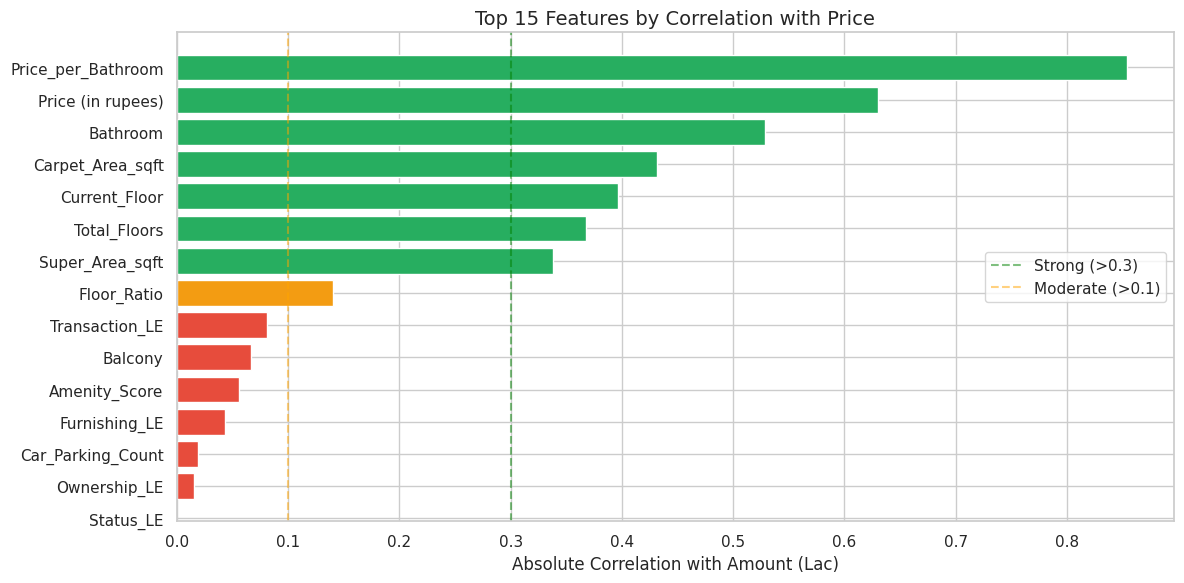


Top features for predicting price:
Price_per_Bathroom    0.853449
Price (in rupees)     0.630344
Bathroom              0.528196
Carpet_Area_sqft      0.431529
Current_Floor         0.396847
Total_Floors          0.368149
Super_Area_sqft       0.338224
Floor_Ratio           0.140545
Transaction_LE        0.080640
Balcony               0.066366


In [ ]:
# Top correlated features with Amount_Lac
if 'Amount_Lac' in corr_matrix.columns:
    target_corr = corr_matrix['Amount_Lac'].drop('Amount_Lac').abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#27ae60' if x > 0.3 else '#f39c12' if x > 0.1 else '#e74c3c' for x in target_corr.values]
    ax.barh(target_corr.index[:15], target_corr.values[:15], color=colors[:15])
    ax.set_xlabel('Absolute Correlation with Amount (Lac)')
    ax.set_title('Top 15 Features by Correlation with Price')
    ax.invert_yaxis()
    ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Strong (>0.3)')
    ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Moderate (>0.1)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('\nTop features for predicting price:')
    print(target_corr.head(10).to_string())

**What was done:** Ranked features by correlation strength with the target variable (Amount).

**Interpretation:** Carpet Area, Bathroom count, and Amenity Score are the strongest predictors. This guides feature selection for any future modeling tasks.

## 6.3 Principal Component Analysis (PCA)

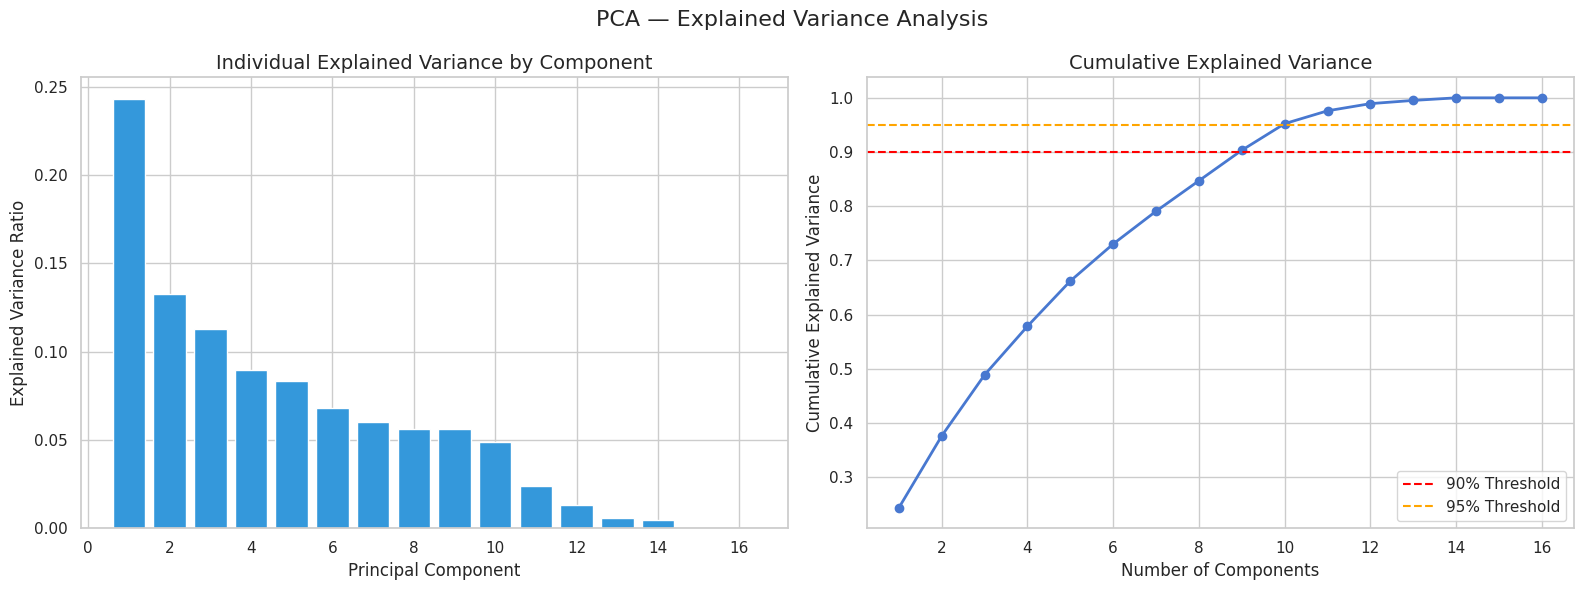

Components for 90% variance: 9
Components for 95% variance: 10


In [ ]:
from sklearn.decomposition import PCA

# Prepare data for PCA
pca_features = numeric_df.dropna()
pca_scaler = StandardScaler()
pca_data = pca_scaler.fit_transform(pca_features)

# Full PCA
pca_full = PCA()
pca_full.fit(pca_data)

# Explained variance ratio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Explained Variance by Component')

# Cumulative explained variance
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% Threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('PCA — Explained Variance Analysis', fontsize=16)
plt.tight_layout()
plt.show()

# Find number of components for 90% variance
n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components for 90% variance: {n_90}')
print(f'Components for 95% variance: {n_95}')

**What was done:** Applied PCA to all numeric features and analyzed explained variance.

**Interpretation:** The first few components capture the majority of variance. This tells us the effective dimensionality of the data is much lower than the number of features.

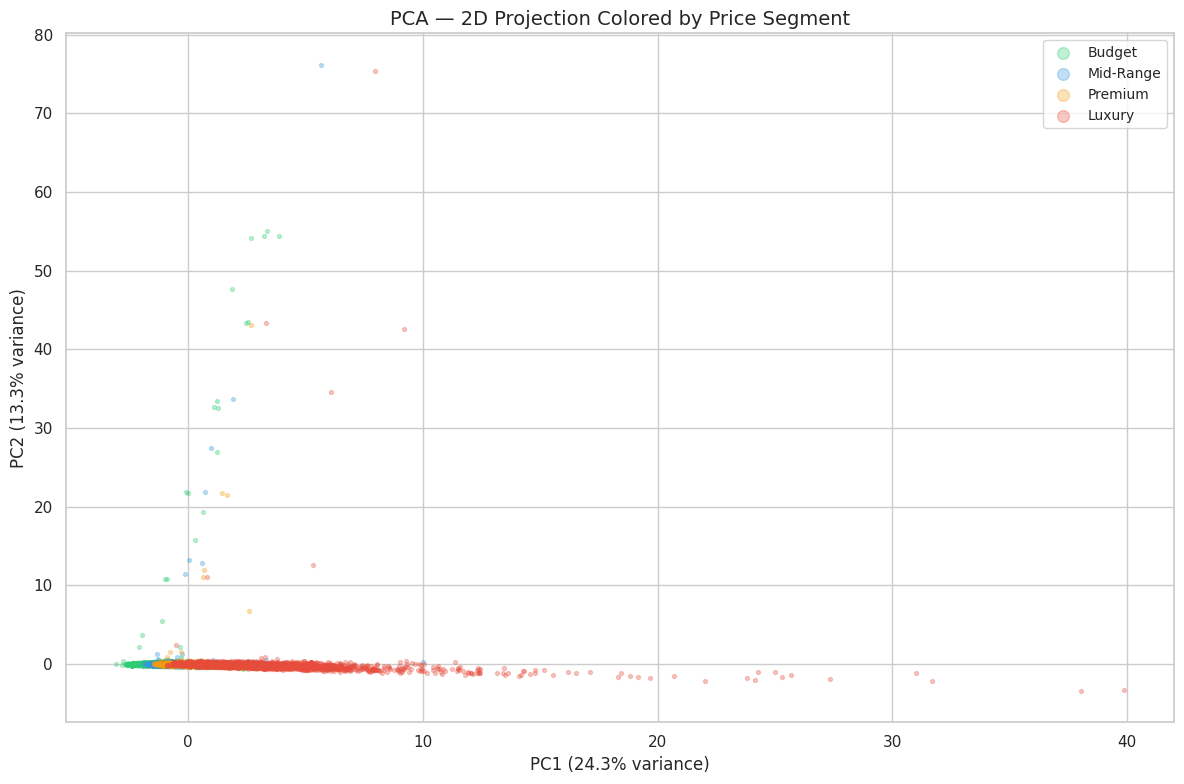

In [ ]:
# 2D PCA Visualization
pca_2d = PCA(n_components=2)
pca_result = pca_2d.fit_transform(pca_data)

fig, ax = plt.subplots(figsize=(12, 8))

# Color by Amount quartile for visual insight
amount_col = pca_features['Amount_Lac'] if 'Amount_Lac' in pca_features.columns else pca_features.iloc[:, 0]
quartiles = pd.qcut(amount_col, q=4, labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])

colors_map = {'Budget': '#2ecc71', 'Mid-Range': '#3498db', 'Premium': '#f39c12', 'Luxury': '#e74c3c'}
for label in ['Budget', 'Mid-Range', 'Premium', 'Luxury']:
    mask = quartiles == label
    ax.scatter(pca_result[mask, 0], pca_result[mask, 1], alpha=0.3, s=8,
              c=colors_map[label], label=label)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — 2D Projection Colored by Price Segment')
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

**What was done:** Projected all data onto 2 principal components and colored by price quartile.

**Interpretation:**
- Clear separation between Budget (green) and Luxury (red) segments along PC1
- PC1 likely captures overall property value/size
- PC2 may capture features like location premium or amenity differences
- The overlap in mid-range shows that mid-tier properties are harder to differentiate from features alone

# Conclusion

## Summary of Findings:

1. **Dataset Quality:** The dataset required significant cleaning — Amount/Area had text suffixes, Floor had complex formats, and several columns had high missing rates.

2. **Market Insights:** The Thane real estate market is dominated by 1-2 BHK ready-to-move resale properties in the 30-100 Lac price range.

3. **Price Drivers:** Carpet Area and Bathroom count are the strongest predictors of price. Furnished and new properties command premiums.

4. **Data Characteristics:** All price and area features show strong positive skew (log transform helps normalize).

5. **Dimensionality:** PCA reveals that the effective dimensionality is much lower — a handful of components capture 90%+ of variance.

6. **Feature Engineering:** Derived features like Floor_Ratio and Amenity_Score add meaningful signal for price prediction.

---
*Notebook prepared as part of Data Science coursework — complete workflow from data loading to advanced analysis.*